# End to End Car Price Intelligence System

## Projenin Amacı:
Bu projenin amacı ikinci el araba verilerini analiz ederek araç fiyatlarını etkileyen faktörleri anlamak ve bu verilere dayanarak bir fiyat tahmin modeli oluşturmaktır.

## Neden önce veri anlaşılır?
Gerçek dünyada veri bilimciler sadece model kurmaz. Öncelikle veriyi anlamak, temizlemek ve analiz etmek gerekir. Eğer veri doğru anlaşılmazsa kurulan model güvenilir sonuçlar vermez.

## Projenin Aşamaları:
1. Veriyi inceleme ve yapısını anlama  
2. Veri temizleme ve uç değerleri kontrol etme  
3. Grafiksel veri analizi (EDA)  
4. Fiyatı etkileyen değişkenleri inceleme  
5. TensorFlow kullanarak fiyat tahmin modeli oluşturma  
6. Model performansını değerlendirme  
7. Sonuçları yorumlama


In [24]:
import pandas as pd
import numpy as np
#Araba markası, model yılı, kilometre, motor gücü, araç yaşı, fiyat verileri var.

n_size = 900
current_year = 2026

data = {
    "brand": np.random.choice(["Audi","Mercedes","Range Rover","Honda","Toyota","BMW","Fiat","Hyundai"], n_size),
    "model_year": np.random.randint(2006, 2025, n_size),
    "kilometers": np.random.randint(7000, 300000, n_size),
    "engine_power" : np.random.randint(50, 350, n_size)

}


df = pd.DataFrame(data) #df oluşturduk

#araç yaşı hesaplama
df["car_age"] = current_year - df["model_year"]

#fiyatı oluşturalım
df["price"] = (
    320000
    + df["engine_power"] * 1200
    - df["kilometers"] * 0.12
    - df["car_age"] * 8000
    + np.random.normal(0, 40000, n_size)
)

#fiyat negatif olmasın 
df["price"] = df["price"].clip(lower=50000)

#eksik değer ekleyelim
df.loc[np.random.choice(df.index, 8, replace=False), "engine_power"] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), "price"] = np.nan

#uç değer ekleyelim
df.loc[np.random.choice(df.index, 4, replace=False), "kilometers"] = 850000
df.loc[np.random.choice(df.index, 3, replace=False), "price"] = 1500000


df.head()

,brand,model_year,kilometers,engine_power,car_age,price
0,Range Rover,2017,10743,327.0,9,704888.777488
1,Toyota,2009,287877,92.0,17,244809.438425
2,Range Rover,2008,223208,263.0,18,443653.151544
3,Fiat,2012,134422,278.0,14,516044.812637
4,Mercedes,2010,135243,249.0,16,475986.818239


## Veriyi Anlamak

In [25]:
df.info()
print(" ")
print(" ")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         900 non-null    str    
 1   model_year    900 non-null    int64  
 2   kilometers    900 non-null    int64  
 3   engine_power  892 non-null    float64
 4   car_age       900 non-null    int64  
 5   price         895 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 42.3 KB
 
 


,model_year,kilometers,engine_power,car_age,price
count,900.000000,900.000000,892.000000,900.000000,8.950000e+02
mean,2014.946667,157300.435556,202.354260,11.053333,4.606809e+05
std,5.415078,95611.379541,86.493028,5.415078,1.338952e+05
min,2006.000000,7017.000000,50.000000,2.000000,1.216056e+05
25%,2010.000000,80466.250000,125.000000,6.750000,3.586266e+05
50%,2015.000000,153141.000000,208.000000,11.000000,4.600053e+05
75%,2019.250000,228107.250000,279.000000,16.000000,5.474212e+05
max,2024.000000,850000.000000,349.000000,20.000000,1.500000e+06


## Grafiksel Analizler

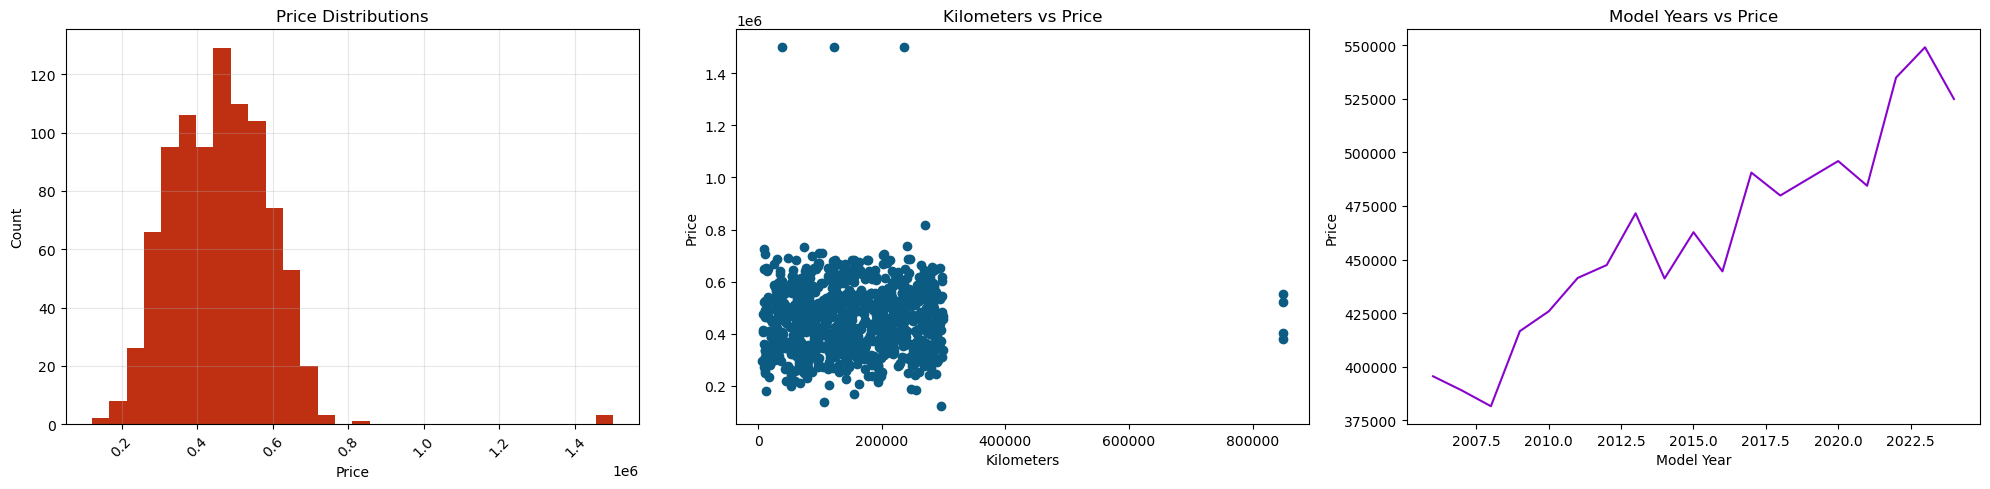

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

##Fiyat dağılımı (histogram)
plt.subplot(1,3,1) #1 row, 3 sütun, 1 grafik
plt.hist(df["price"], bins=30, color="#BF2F12") #bins=30 fiyat aralığını 30 parçaya böl demek
plt.title("Price Distributions")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)


#Kilometre vs Fiyat (scatter)
plt.subplot(1,3,2)
plt.scatter(df["kilometers"], df["price"], color="#0C5B82")
plt.title("Kilometers vs Price")
plt.xlabel("Kilometers")
plt.ylabel("Price")


# yıl vs fiyat (line/scatter)
# yıla göre ortalama fiyat
year_price = df.groupby("model_year")["price"].mean()
plt.subplot(1,3,3)
#plt.scatter(df["model_year"], df["price"], color="#60D41C")
plt.plot(year_price.index, year_price.values, color="#8704CD")

plt.title("Model Years vs Price")
plt.xlabel("Model Year")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

## En yüksek fiyatlı arabalar

In [27]:
#En pahalı 10 aracı bulalım ve bu araçların ortak özelliklerini yorumlayalım
top_ten_expensive_cars = df.sort_values(by="price", ascending=False).head(10) #sort_values ile büyükten küçüğe sıraladı 

# Verinin genel ortalamasını görmek için:
avg_price = df['price'].mean()
print(f"Overall price average: {avg_price:,.2f} TL")

top_ten_expensive_cars
### En Pahalı Araçların Analizi
#Veri setindeki en pahalı 10 araç incelendiğinde bazı ortak özellikler görülmektedir.
#- Bu araçların çoğu yüksek motor gücüne sahiptir (320–348 HP aralığı).
#- Araçların büyük bölümü 2021–2024 model yıllarına aittir.
#- Araç yaşı genellikle 2–5 yıl arasındadır, yani oldukça yenidir.
#- En pahalı araçlar arasında Mercedes, BMW, Audi ve Range Rover gibi premium markalar öne çıkmaktadır.

#Bu gözlemler, araç fiyatını en çok etkileyen faktörlerin:
#- motor gücü
#- araç yaşı / model yılı
#- marka olabileceğini göstermektedir. Bu değişkenler, ileride kurulacak fiyat tahmin modelinde önemli rol oynayabilir.

Overall price average: 460,680.88 TL


,brand,model_year,kilometers,engine_power,car_age,price
892,Honda,2023,236163,96.0,3,1.500000e+06
188,Toyota,2022,37909,51.0,4,1.500000e+06
231,Fiat,2017,122281,175.0,9,1.500000e+06
88,Toyota,2024,269608,337.0,2,8.176124e+05
177,Toyota,2022,240973,340.0,4,7.377480e+05
646,Hyundai,2020,74402,323.0,6,7.329794e+05
283,Fiat,2022,10194,305.0,4,7.245454e+05
299,Fiat,2023,99098,296.0,3,7.102687e+05
700,Range Rover,2019,104013,347.0,7,7.092391e+05
419,Mercedes,2013,203684,323.0,13,7.059369e+05


## Veri Temizliği

In [28]:
#eksik değer kontrol edelim
nullValues = df.isnull().sum() #eksik boş veri var mı diye baktık engine_power'da 8  tane, price'da 5 tane eksik değer var
nullValues

#outlier var mı bakalım
print("\n850000 km üzeri araç sayısı:", (df["kilometers"] > 400000).sum())
print("1.000.000 TL üzeri araç sayısı:", (df["price"] > 1000000).sum())

#temizlik öncesi veri sayısı
print("Temizlik öncesi veri sayısı: ", (len(df)))


# VERİ TEMİZLEME
#eksik değerleri silelim:
df = df.dropna()

#kilometredeki uç değerleri silelim
df = df[df["kilometers"] <= 400000]

#aşırı fiyat uç değerlerini sileilm
df = df[df["price"] <= 1000000]

#temizlik sonrası veri sayısı
print("Temizlik sonrası veri sayısı: ", (len(df)))

### Veri Temizleme Süreci

#Veri seti modelleme öncesinde eksik değerler ve uç değerler açısından incelenmiştir.
#Eksik Değerler: engine_power ve price sütunlarında bazı kayıtların eksik olduğu görülmüştür. Eksik değerler modelin hatalı öğrenmesine neden olabileceği için bu kayıtlar veri setinden kaldırılmıştır.
# Uç Değerler: Kilometre sütununda 850000 km gibi gerçekçi olmayan değerler tespit edilmiştir. Bu değerler uç değer olarak değerlendirilmiş ve veri setinden çıkarılmıştır.
# Fiyat sütununda ise 1.500.000 TL gibi veri dağılımına göre aşırı yüksek fiyatlar bulunmuştur. Bu kayıtlar modelin öğrenme sürecini bozabileceği için veri setinden kaldırılmıştır.
# Bu işlemler sonucunda veri seti daha tutarlı hale getirilmiş ve modelleme için uygun bir yapı elde edilmiştir.


850000 km üzeri araç sayısı: 4
1.000.000 TL üzeri araç sayısı: 3
Temizlik öncesi veri sayısı:  900
Temizlik sonrası veri sayısı:  880


## Feature ve Target Hazırlığı

In [29]:
#Features x
X = df[["model_year", "kilometers", "engine_power", "car_age"]]
#Target y
y = df["price"]

# Basit normalizasyon
X_normalized = (X - X.min()) / (X.max() - X.min())

#y'yi de normakize ediyorum
y_normalized = (y - y.min()) / (y.max() - y.min())

X_normalized.head()

,model_year,kilometers,engine_power,car_age
0,0.611111,0.012736,0.926421,0.388889
1,0.166667,0.960048,0.140468,0.833333
2,0.111111,0.738993,0.712375,0.888889
3,0.333333,0.435501,0.762542,0.666667
4,0.222222,0.438308,0.665552,0.777778


## Model Oluşturma

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

#model oluşturma
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1)
])

model.summary()

### Model Yapısı
#Bu projede araç fiyatını tahmin etmek için basit bir yapay sinir ağı (ANN) modeli oluşturulmuştur.
#Model Sequential yapısı kullanılarak oluşturulmuştur ve iki gizli katman içermektedir.
# İlk gizli katman: 16 nöron ve ReLU aktivasyon fonksiyonu
# İkinci gizli katman: 8 nöron ve ReLU aktivasyon fonksiyonu
# Çıkış katmanı: 1 nöron (fiyat tahmini için)
#Model optimizasyonu için Adam optimizer, hata ölçümü için ise Mean Squared Error (MSE) kullanılacak.
#Bu yapı, fiyat tahmini gibi regresyon problemleri için yeterli ve basit bir mimari sunmaktadır.

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 16)                80        
                                                                 
 dense_16 (Dense)            (None, 8)                 136       
                                                                 
 dense_17 (Dense)            (None, 1)                 9         
                                                                 
Total params: 225 (900.00 Byte)
Trainable params: 225 (900.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Model Eğitimi

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_normalized, test_size=0.2, random_state=42)

#model derleme
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

#model eğitimi
history = model.fit(X_train, y_train, epochs = 60, batch_size=32, validation_split=0.2, verbose=0)
print("Your model's training is complete.")

Your model's training is complete.


## Sonuçları değerlendirmek

Test MSE: 0.00
Test MAE: 0.05
6/6 [==============================] - 0s 1ms/step
Real Test MSE: 2,026,443,214.61 TL
Real Test MAE: 36,367.60 TL


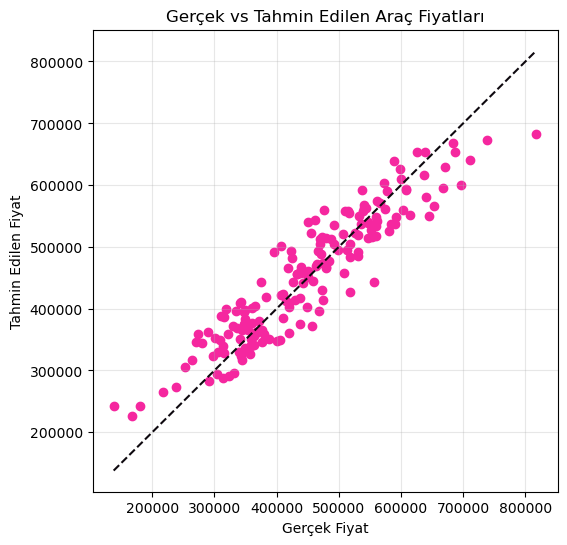

In [33]:
# test performansı
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Test MSE: {test_loss:,.2f}")
print(f"Test MAE: {test_mae:,.2f}")

# tahmin yap
y_pred = model.predict(X_test)


# gerçek ölçeğe geri çevir
y_test_real = y_test * (y.max() - y.min()) + y.min() #0-1 arasından çıkarıp gerçek ölçeğe çevirdik
y_pred_real = y_pred * (y.max() - y.min()) + y.min()

#numpy array yapalım
y_test_real = np.array(y_test_real).flatten() #matplotlib tek boyutlu array ister o yüzden düzelttik
y_pred_real = np.array(y_pred_real).flatten()

# gerçek hata hesaplama
real_mae = mean_absolute_error(y_test_real, y_pred_real)
real_mse = mean_squared_error(y_test_real, y_pred_real)
print(f"Real Test MSE: {real_mse:,.2f} TL")
print(f"Real Test MAE: {real_mae:,.2f} TL")

#grafik kısmı
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, color="#F5279F")

#ideal tahmin çizgisi
plt.plot([y_test_real.min(), y_test_real.max()],[y_test_real.min(), y_test_real.max()],color="#0E090F",linestyle="--")
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Edilen Fiyat")
plt.title("Gerçek vs Tahmin Edilen Araç Fiyatları")
plt.grid(alpha=0.3)
plt.show()


#Model Performans Değerlendirmesi:
#Model test veri seti üzerinde değerlendirilmiştir. Normalize edilmiş sonuçlara göre:
#   -Test MSE: 0.00
#   -Test MAE: 0.05
#Bu değerler modelin normalize edilmiş veri üzerinde düşük hata (%5 ort hata) ile tahmin yaptığını göstermektedir.
#Gerçek fiyat ölçeğinde hesaplanan sonuçlara göre model: Ortalama ≈ 36,367 TL hata ile araç fiyatını tahmin edebilmektedir.
#Veri setindeki ortalama araç fiyatının yaklaşık 457,000 TL olduğu düşünüldüğünde bu hata oranı yaklaşık %7 civarındadır.
#Gerçek ve tahmin edilen fiyatların karşılaştırıldığı grafikte noktaların büyük kısmının ideal tahmin çizgisine yakın olduğu görülmektedir. 
#Bu durum modelin araç fiyatlarını genel olarak başarılı şekilde tahmin edebildiğini göstermektedir.
#Model özellikle orta fiyat aralığında daha başarılı görünmektedir. 
#Bazı yüksek veya düşük fiyatlı araçlarda ise tahmin hataları artabilmektedir.

## Yönetici Özeti
- **Model Ortalama tahmin hatası: 36,000 TL**
- **Model araç fiyatlarını genel olarak başarılı şekilde tahmin etti**
- **Model ikinci el araç fiyat tahmini için kullanılabilir**
- **Orta fiyat bandındaki araçlarda tahminler daha isabetli oldu**
- **Uç fiyatlı araçlarda tahmin hatası bir miktar arttı**
- **Daha fazla veri ve marka bazlı özelliklerle model performansı artırılabilir**

